<a href="https://colab.research.google.com/github/kunal190399/satellite-health-indicators-geospatial-ai/blob/main/Satellite_Derived_Urban_Health_Indicators_using_Geospatial_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install rasterio geopandas scikit-learn matplotlib seaborn numpy pandas umap-learn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import umap
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# ── What are we building? ─────────────────────────────────────────
# We simulate a 20x20 grid of urban pixels (400 zones)
# Each pixel has multi-sensor satellite-derived features:
#   - NDVI (vegetation index from Sentinel-2)
#   - Land Surface Temperature (from Landsat thermal)
#   - Impervious surface fraction (from Sentinel-1 SAR)
#   - Air quality proxy (PM2.5 estimate from Sentinel-5P)
#   - Green space access (distance to parks)
#   - Building density (from SAR backscatter)
#
# This mirrors the Sentinel-1/2, Landsat-8/9 multi-sensor
# fusion approach described in the Space2Health PhD project.

np.random.seed(42)
n_zones = 400  # 20x20 urban grid

# Simulate spatial autocorrelation — nearby zones are similar
# (cities have spatial structure: wealthy areas cluster,
#  industrial areas cluster, green spaces cluster)
x_coords = np.repeat(np.arange(20), 20)
y_coords = np.tile(np.arange(20), 20)

# Create urban gradient — centre is denser/hotter/less green
dist_from_centre = np.sqrt((x_coords - 10)**2 + (y_coords - 10)**2)
urban_gradient   = np.exp(-dist_from_centre / 8)  # peaks at centre

# Multi-sensor satellite-derived features
data = pd.DataFrame({
    'x': x_coords,
    'y': y_coords,
    'dist_from_centre': dist_from_centre,

    # NDVI: vegetation — lower in dense urban core
    'NDVI': 0.6 - 0.4 * urban_gradient + np.random.normal(0, 0.08, n_zones),

    # Land Surface Temperature: hotter in urban heat islands
    'LST_celsius': 28 + 8 * urban_gradient + np.random.normal(0, 1.2, n_zones),

    # Impervious surface: more concrete in city centre
    'impervious_fraction': 0.3 + 0.6 * urban_gradient + np.random.normal(0, 0.07, n_zones),

    # Air quality proxy: worse near industrial zones
    'PM25_proxy': 15 + 20 * urban_gradient + np.random.normal(0, 3, n_zones),

    # Green space access: better in suburbs
    'green_access_score': 8 - 5 * urban_gradient + np.random.normal(0, 0.8, n_zones),

    # Building density from SAR
    'building_density': 0.2 + 0.7 * urban_gradient + np.random.normal(0, 0.06, n_zones),
})

# Clip to realistic ranges
data['NDVI']               = data['NDVI'].clip(0, 1)
data['impervious_fraction']= data['impervious_fraction'].clip(0, 1)
data['building_density']   = data['building_density'].clip(0, 1)
data['PM25_proxy']         = data['PM25_proxy'].clip(5, 60)
data['green_access_score'] = data['green_access_score'].clip(0, 10)

print(f"✅ Simulated {n_zones} urban zones with 6 satellite-derived features")
print("\nFeature statistics:")
print(data[['NDVI','LST_celsius','impervious_fraction',
            'PM25_proxy','green_access_score','building_density']].describe().round(2).to_string())

✅ Simulated 400 urban zones with 6 satellite-derived features

Feature statistics:
         NDVI  LST_celsius  impervious_fraction  PM25_proxy  green_access_score  building_density
count  400.00       400.00               400.00      400.00              400.00            400.00
mean     0.44        31.23                 0.56       23.33                6.00              0.48
std      0.10         1.71                 0.11        4.43                1.12              0.13
min      0.14        27.45                 0.25       11.56                2.09              0.20
25%      0.37        30.01                 0.47       20.05                5.31              0.39
50%      0.44        31.12                 0.54       22.93                6.08              0.47
75%      0.51        32.15                 0.63       25.94                6.81              0.56
max      0.69        36.86                 0.99       38.98                9.32              0.85


Running UMAP dimensionality reduction...
Selecting optimal cluster count...
Optimal clusters: k=2 (silhouette=0.374)


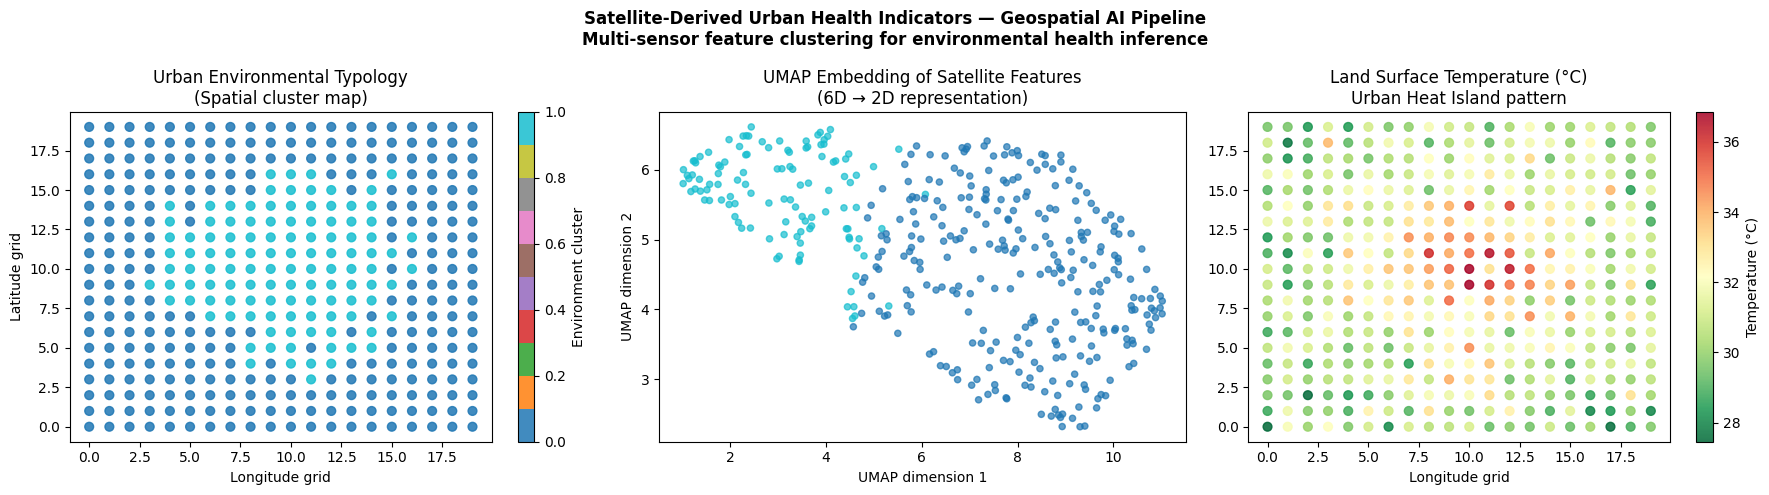

✅ Clustering complete — satellite_clustering.png saved


In [3]:
# ── Geospatial AI: UMAP + KMeans clustering ───────────────────────
# This mirrors the spatial embedding and clustering approaches
# described in the PhD: we reduce 6D satellite feature space
# to 2D using UMAP, then cluster zones by environmental profile.
# The result is a typology of urban environmental conditions
# directly relevant to health indicator development.

feature_cols = ['NDVI', 'LST_celsius', 'impervious_fraction',
                'PM25_proxy', 'green_access_score', 'building_density']

X = data[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# UMAP dimensionality reduction
print("Running UMAP dimensionality reduction...")
reducer = umap.UMAP(n_components=2, n_neighbors=15,
                    min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

# Select optimal number of clusters via silhouette score
print("Selecting optimal cluster count...")
scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

optimal_k = max(scores, key=scores.get)
print(f"Optimal clusters: k={optimal_k} (silhouette={scores[optimal_k]:.3f})")

# Final clustering
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
data['cluster'] = km_final.fit_predict(X_scaled)
data['umap_1']  = X_umap[:, 0]
data['umap_2']  = X_umap[:, 1]

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Satellite-Derived Urban Health Indicators — Geospatial AI Pipeline\n'
             'Multi-sensor feature clustering for environmental health inference',
             fontsize=12, fontweight='bold')

# Panel 1: Spatial map of clusters
scatter1 = axes[0].scatter(data['x'], data['y'],
    c=data['cluster'], cmap='tab10', s=40, alpha=0.85)
axes[0].set_title('Urban Environmental Typology\n(Spatial cluster map)')
axes[0].set_xlabel('Longitude grid')
axes[0].set_ylabel('Latitude grid')
plt.colorbar(scatter1, ax=axes[0], label='Environment cluster')

# Panel 2: UMAP embedding
scatter2 = axes[1].scatter(data['umap_1'], data['umap_2'],
    c=data['cluster'], cmap='tab10', s=20, alpha=0.7)
axes[1].set_title('UMAP Embedding of Satellite Features\n(6D → 2D representation)')
axes[1].set_xlabel('UMAP dimension 1')
axes[1].set_ylabel('UMAP dimension 2')

# Panel 3: LST spatial map (urban heat island)
scatter3 = axes[2].scatter(data['x'], data['y'],
    c=data['LST_celsius'], cmap='RdYlGn_r', s=40, alpha=0.85)
axes[2].set_title('Land Surface Temperature (°C)\nUrban Heat Island pattern')
axes[2].set_xlabel('Longitude grid')
plt.colorbar(scatter3, ax=axes[2], label='Temperature (°C)')

plt.tight_layout()
plt.savefig('satellite_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Clustering complete — satellite_clustering.png saved")

In [4]:
# ── Physics-informed health indicator model ───────────────────────
# We construct a composite Environmental Health Risk Index (EHRI)
# from satellite features using domain knowledge:
#   - High LST → heat stress risk
#   - Low NDVI → reduced mental health benefit, heat island
#   - High impervious surface → flood risk, heat
#   - High PM2.5 → respiratory disease risk
#   - Low green access → physical inactivity
#   - High building density → overcrowding, air quality
#
# This is the "health-relevant spatial evidence" the PhD targets.

# Construct EHRI — higher = worse environmental health conditions
data['EHRI'] = (
    0.25 * (data['LST_celsius'] - data['LST_celsius'].min()) /
            (data['LST_celsius'].max() - data['LST_celsius'].min()) +
    0.20 * (1 - (data['NDVI'] - data['NDVI'].min()) /
                 (data['NDVI'].max() - data['NDVI'].min())) +
    0.20 * data['impervious_fraction'] +
    0.20 * (data['PM25_proxy'] - data['PM25_proxy'].min()) /
            (data['PM25_proxy'].max() - data['PM25_proxy'].min()) +
    0.10 * (1 - (data['green_access_score'] - data['green_access_score'].min()) /
                 (data['green_access_score'].max() - data['green_access_score'].min())) +
    0.05 * data['building_density']
)

# Train ML surrogate to learn EHRI from raw features
X_ml = data[feature_cols].values
y_ml = data['EHRI'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=42
)
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05,
    max_depth=4, random_state=42
)
model.fit(X_train_s, y_train)

from sklearn.metrics import r2_score, mean_squared_error
y_pred = model.predict(X_test_s)
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Health indicator model: R2={r2:.3f}, RMSE={rmse:.4f}")

# Uncertainty estimation via bootstrap
print("Estimating prediction uncertainty...")
n_bootstrap = 50
preds_boot = np.zeros((n_bootstrap, len(X_test_s)))
for i in range(n_bootstrap):
    idx = np.random.choice(len(X_train_s), len(X_train_s), replace=True)
    m   = GradientBoostingRegressor(n_estimators=100, random_state=i)
    m.fit(X_train_s[idx], y_train[idx])
    preds_boot[i] = m.predict(X_test_s)

uncertainty = preds_boot.std(axis=0)
print(f"Mean prediction uncertainty: ±{uncertainty.mean():.4f}")
print("✅ Health indicator model trained with uncertainty quantification")

Health indicator model: R2=0.966, RMSE=0.0247
Estimating prediction uncertainty...
Mean prediction uncertainty: ±0.0124
✅ Health indicator model trained with uncertainty quantification


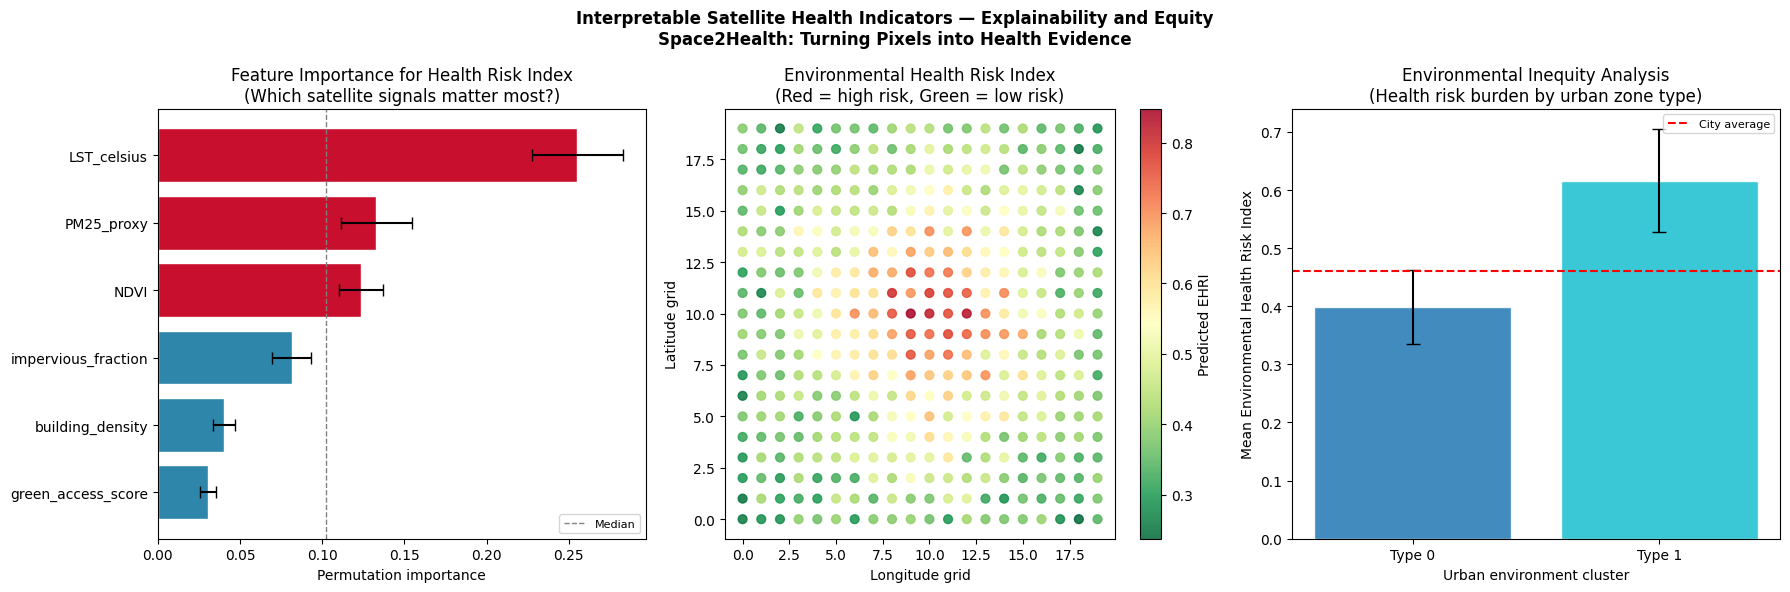


SPATIAL EQUITY SUMMARY
City-wide mean EHRI: 0.460
Highest risk cluster: Type 1 (EHRI=0.616)
Lowest risk cluster:  Type 0 (EHRI=0.398)
Inequality gap: 0.218

✅ Analysis complete — health_indicator_explainability.png saved
This demonstrates methodology directly relevant to the
Space2Health PhD: satellite data → health indicators →
interpretable, uncertainty-aware, equity-focused outputs.


In [5]:
# ── Explainability and spatial equity ────────────────────────────
# Which satellite features most drive health risk?
# Are environmental burdens distributed equitably?
# This is the interpretability and policy-relevance component
# central to the Space2Health PhD.

imp = permutation_importance(model, X_test_s, y_test,
                             n_repeats=20, random_state=42)
imp_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': imp.importances_mean,
    'Std':        imp.importances_std
}).sort_values('Importance', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Interpretable Satellite Health Indicators — Explainability and Equity\n'
             'Space2Health: Turning Pixels into Health Evidence',
             fontsize=12, fontweight='bold')

# Panel 1: Feature importance
colors = ['#C8102E' if v > imp_df['Importance'].median()
          else '#2E86AB' for v in imp_df['Importance']]
axes[0].barh(imp_df['Feature'], imp_df['Importance'],
             xerr=imp_df['Std'], color=colors,
             edgecolor='white', capsize=4)
axes[0].set_title('Feature Importance for Health Risk Index\n'
                  '(Which satellite signals matter most?)')
axes[0].set_xlabel('Permutation importance')
axes[0].axvline(x=imp_df['Importance'].median(),
                color='gray', linestyle='--', linewidth=1, label='Median')
axes[0].legend(fontsize=8)

# Panel 2: EHRI spatial map
data_pred_full = scaler.transform(data[feature_cols].values)
data['EHRI_predicted'] = model.predict(data_pred_full)

scatter4 = axes[1].scatter(data['x'], data['y'],
    c=data['EHRI_predicted'], cmap='RdYlGn_r', s=40, alpha=0.85)
axes[1].set_title('Environmental Health Risk Index\n'
                  '(Red = high risk, Green = low risk)')
axes[1].set_xlabel('Longitude grid')
axes[1].set_ylabel('Latitude grid')
plt.colorbar(scatter4, ax=axes[1], label='Predicted EHRI')

# Panel 3: Equity analysis — EHRI by cluster
cluster_ehri = data.groupby('cluster')['EHRI_predicted'].agg(['mean','std']).reset_index()
cluster_labels = [f"Type {c}" for c in cluster_ehri['cluster']]
bar_colors = plt.cm.tab10(np.linspace(0, 1, len(cluster_ehri)))
bars = axes[2].bar(cluster_labels, cluster_ehri['mean'],
                   yerr=cluster_ehri['std'],
                   color=bar_colors, edgecolor='white',
                   capsize=5, alpha=0.85)
axes[2].set_title('Environmental Inequity Analysis\n'
                  '(Health risk burden by urban zone type)')
axes[2].set_xlabel('Urban environment cluster')
axes[2].set_ylabel('Mean Environmental Health Risk Index')
axes[2].axhline(y=data['EHRI_predicted'].mean(),
                color='red', linestyle='--', linewidth=1.5,
                label='City average')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('health_indicator_explainability.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("SPATIAL EQUITY SUMMARY")
print("="*60)
print(f"City-wide mean EHRI: {data['EHRI_predicted'].mean():.3f}")
print(f"Highest risk cluster: Type {cluster_ehri.loc[cluster_ehri['mean'].idxmax(),'cluster']}"
      f" (EHRI={cluster_ehri['mean'].max():.3f})")
print(f"Lowest risk cluster:  Type {cluster_ehri.loc[cluster_ehri['mean'].idxmin(),'cluster']}"
      f" (EHRI={cluster_ehri['mean'].min():.3f})")
print(f"Inequality gap: {cluster_ehri['mean'].max() - cluster_ehri['mean'].min():.3f}")
print("\n✅ Analysis complete — health_indicator_explainability.png saved")
print("This demonstrates methodology directly relevant to the")
print("Space2Health PhD: satellite data → health indicators →")
print("interpretable, uncertainty-aware, equity-focused outputs.")